In [1]:
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

In [2]:
class SRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=2, output_dim=1):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.context_dim = self.hidden_dim
        self.output_dim = output_dim

        self.in_to_hidden = nn.Linear(self.input_dim, self.hidden_dim)
        self.ctx_to_hidden = nn.Linear(self.context_dim, self.hidden_dim, bias=False) # in_to_hidden already has a bias
        self.hidden_to_out = nn.Linear(self.hidden_dim, self.output_dim)

    def init_context(self):
        return torch.full((self.hidden_dim,), 0.5)

    def forward(self, x, ctx):
        x1 = self.in_to_hidden(x)
        x2 = self.ctx_to_hidden(ctx)
        hidden = x1 + x2
        hidden_act = hidden.sigmoid()
        out = self.hidden_to_out(hidden_act)
        return out, hidden_act

In [3]:
def xor_sequence(n_triples):
    pairs = torch.randint(0, 2, (n_triples, 2))
    xor = pairs.sum(dim=1, keepdim=True) % 2
    return torch.cat([pairs, xor], dim=1).reshape(-1, 1).float()

seq = xor_sequence(1000)
X, y = seq[:-1], seq[1:]

In [4]:
def train(model, X, y, epochs, lr):
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    for epoch in range(1, epochs+1):
        ctx = model.init_context()
        loss_total = 0.0
        for x_item, y_item in zip(X, y):
            logits, hidden = model(x_item, ctx)
            prob = torch.sigmoid(logits)
            loss = F.mse_loss(prob, y_item)
            loss_total += loss.item()

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            ctx = hidden.detach()

        if epoch % 10 == 0:
            print(f"epoch {epoch:4d}  mean loss {loss_total / len(X):.4f}")

@torch.no_grad()
def predict(model, X):
    ctx = model.init_context()
    probs = []
    for x_item in X:
        logits, hidden = model(x_item, ctx)
        probs.append(torch.sigmoid(logits))
        ctx = hidden
    return torch.stack(probs)

In [16]:
hidden_dim = 2

model = SRNN(hidden_dim=hidden_dim)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 11


In [ ]:
num_epochs = 100
lr = 0.1
train(model, X, y, num_epochs, lr)
probs = predict(model, X)

epoch   10  mean loss 0.2512
epoch   20  mean loss 0.2510
epoch   30  mean loss 0.2509
epoch   40  mean loss 0.2505
epoch   50  mean loss 0.2473
epoch   60  mean loss 0.2284
epoch   70  mean loss 0.2250
epoch   80  mean loss 0.2237
epoch   90  mean loss 0.2232
epoch  100  mean loss 0.2229


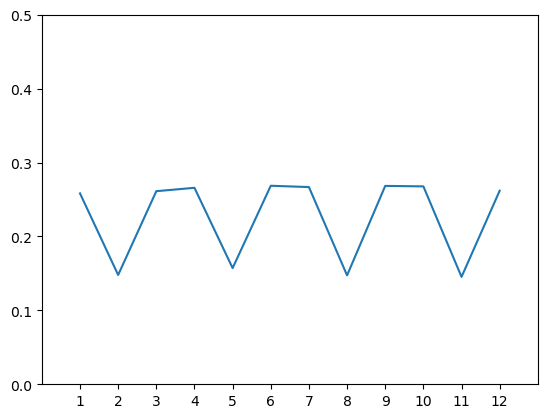

In [17]:
import matplotlib.pyplot as plt

squared_errors = (probs - y).square()
squared_errors = squared_errors[:(len(squared_errors)//12)*12]
phase_mse = squared_errors.reshape(-1, 12).mean(dim=0)
phase_rmse = phase_mse.sqrt()

xs = np.arange(1, len(phase_mse)+1)
plt.plot(xs, phase_mse)
plt.xticks(xs)
plt.xlim(0, 13)
plt.ylim(0, 0.5)

plt.show()

![alt text](image.png)